# Aula prática de classificação: do EDA à avaliação crítica do modelo

**Autor:** Lucas Mascarenhas Almeida  
**GitHub:** [mascalmeida](https://github.com/mascalmeida)  
**E-mail:** lucasmascalmeida@gmail.com  
**LinkedIn:** [lucas-mascarenhas](https://www.linkedin.com/in/lucas-mascarenhas/)  

**Referência principal:** *An Introduction to Statistical Learning with Applications in Python* — ISLP.

---

## Perguntas-guia da aula

1. O que diferencia uma análise exploratória de uma etapa de modelagem?
2. Como um modelo de classificação transforma variáveis de entrada em uma decisão?
3. Como saber se um modelo está aprendendo algo útil ou apenas reproduzindo a classe majoritária?
4. Como nossas decisões de pré-processamento afetam a avaliação final?
5. Como comparar modelos diferentes de forma justa?


## Antes de começar: perguntas de orientação

1. Qual problema queremos resolver?
2. Qual decisão um modelo poderia apoiar?
3. Qual seria a classe positiva neste tipo de problema?
4. Qual erro poderia ser mais caro: falso positivo ou falso negativo?
5. Como podemos transformar um problema real em uma pergunta de classificação?
6. Como podemos organizar um ciclo de trabalho baseado em hipótese, experimento, evidência e diagnóstico?


# Preparação do ambiente

In [1]:
# No Google Colab, esta biblioteca costuma instalar rapidamente.
# Ela será usada no Ato 3, quando testarmos SMOTE.

!pip -q install imbalanced-learn

In [57]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Ato 1 — Classificação e análise exploratória

## 1.1 Debate introdutório: o que é classificação?

### Perguntas para a turma

1. O que é um modelo de classificação?
2. Qual é a diferença entre classificação e regressão?
3. Quais problemas reais podem ser formulados como classificação?
4. O que significa dizer que a variável resposta é categórica?
5. Em uma classificação binária, o que significam as classes `0` e `1`?
6. Em um problema real, errar a classe `0` tem o mesmo custo que errar a classe `1`?
7. Como saber se um problema deve ser tratado como classificação binária, multiclasse ou regressão?


## 1.2 Ingestão dos dados

### Perguntas para debate

1. De onde vêm os dados?
2. Cada linha e cada coluna parecem representar o quê?
3. Que problemas podem aparecer logo na leitura dos dados?


In [3]:
url = "https://raw.githubusercontent.com/mascalmeida/classification_class_2026/main/data/input_data.csv"

df = pd.read_csv(url)

df.head()

,Cycle,Preset_1,Preset_2,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Fail
0,1,3,6,44.2352,47.6573,46.4418,64.8203,66.4545,44.4832,False
1,2,2,4,60.8072,63.1721,62.0060,80.7144,81.2464,60.2287,False
2,3,2,1,79.0275,83.0322,82.6421,98.2544,98.7852,80.9935,False
3,4,2,3,79.7162,100.5086,122.3623,121.3634,118.6525,80.3156,False
4,5,2,5,39.9891,51.7648,42.5143,61.0379,50.7165,64.2452,False


In [4]:
df.shape

(800, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cycle        800 non-null    int64  
 1   Preset_1     800 non-null    int64  
 2   Preset_2     800 non-null    int64  
 3   Temperature  800 non-null    float64
 4   Pressure     800 non-null    float64
 5   VibrationX   800 non-null    float64
 6   VibrationY   800 non-null    float64
 7   VibrationZ   800 non-null    float64
 8   Frequency    800 non-null    float64
 9   Fail         800 non-null    bool   
dtypes: bool(1), float64(6), int64(3)
memory usage: 57.2 KB


## 1.3 Definindo a variável-alvo

### Perguntas para debate

1. Qual coluna parece ser a variável-alvo?
2. Que tipo de variável é a variável-alvo?
3. O que aconteceria se a variável-alvo entrasse também como variável de entrada?


In [59]:
target = "Fail"

df[target] = df[target].replace({
    True: 1,
    False: 0,
    "True": 1,
    "False": 0,
    "TRUE": 1,
    "FALSE": 0
})

df[target] = df[target].astype(int)

df[target].unique()

array([0, 1])

## 1.4 Primeira checagem de qualidade dos dados

### Perguntas para debate

1. Quais tipos de dados aparecem em cada coluna?
2. Há valores ausentes?
3. Uma coluna com muitos ou poucos valores únicos exige algum cuidado?


In [7]:
resumo_colunas = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "percentual_missing": (100 * df.isna().mean()).round(2),
    "n_unique": df.nunique()
})

resumo_colunas

,tipo,n_missing,percentual_missing,n_unique
Cycle,int64,0,0.0,800
Preset_1,int64,0,0.0,3
Preset_2,int64,0,0.0,8
Temperature,float64,0,0.0,800
Pressure,float64,0,0.0,800
VibrationX,float64,0,0.0,800
VibrationY,float64,0,0.0,800
VibrationZ,float64,0,0.0,800
Frequency,float64,0,0.0,800
Fail,int64,0,0.0,2


## 1.5 Estatísticas descritivas

### Perguntas para debate

1. Quais variáveis têm maiores e menores escalas?
2. Alguma variável parece ter valores extremos?
3. Por que olhar estatísticas descritivas antes de treinar um modelo?


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cycle,800.0,400.5000,231.0844,1.0000,200.7500,400.5000,600.2500,800.0000
Preset_1,800.0,1.9888,0.8059,1.0000,1.0000,2.0000,3.0000,3.0000
Preset_2,800.0,4.5512,2.2932,1.0000,3.0000,5.0000,7.0000,8.0000
Temperature,800.0,69.2635,25.5363,2.0894,51.0401,65.9067,80.5272,255.6078
Pressure,800.0,78.9979,32.5018,3.4803,55.5086,75.0148,99.3025,189.9957
VibrationX,800.0,73.8603,31.2296,3.8463,50.7525,69.3950,90.1951,230.8611
VibrationY,800.0,72.7869,32.7397,10.0577,48.5240,65.5048,94.0756,193.5699
VibrationZ,800.0,71.8662,27.8446,18.7842,50.7876,69.3192,88.8912,230.9511
Frequency,800.0,68.2234,29.1387,4.3801,45.8618,65.6643,90.0975,178.0903
Fail,800.0,0.0825,0.2753,0.0000,0.0000,0.0000,0.0000,1.0000


## 1.6 Distribuição da variável-alvo

### Perguntas para debate

1. As classes estão balanceadas?
2. O que aconteceria se um modelo sempre previsse a classe mais frequente?
3. Acurácia seria uma métrica confiável neste caso?


In [9]:
contagem_classes = df[target].value_counts().sort_index()

resumo_classes = pd.DataFrame({
    "classe": contagem_classes.index,
    "n_observacoes": contagem_classes.values,
    "percentual": (100 * contagem_classes.values / contagem_classes.sum()).round(2)
})

resumo_classes

,classe,n_observacoes,percentual
0,0,734,91.75
1,1,66,8.25


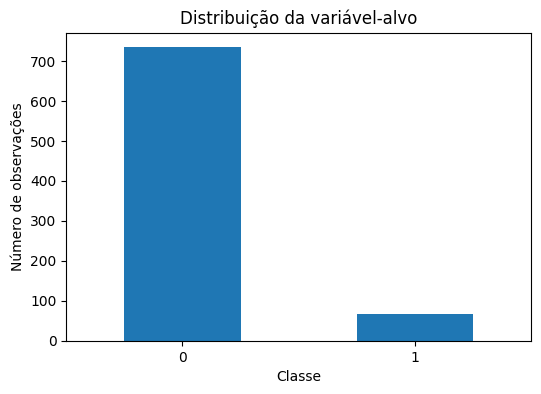

Acurácia de um modelo que sempre prevê a classe majoritária:
91.75%


In [10]:
contagem_classes.plot(kind="bar", figsize=(6, 4))

plt.title("Distribuição da variável-alvo")
plt.xlabel("Classe")
plt.ylabel("Número de observações")
plt.xticks(rotation=0)
plt.show()

acuracia_classe_majoritaria = contagem_classes.max() / contagem_classes.sum()

print("Acurácia de um modelo que sempre prevê a classe majoritária:")
print(f"{acuracia_classe_majoritaria:.2%}")

## 1.7 Escolhendo as variáveis de entrada

### Perguntas para debate

1. Quais colunas devem entrar como variáveis explicativas?
2. Existe alguma coluna que possa gerar vazamento de informação?
3. Como a escolha das variáveis de entrada afeta a interpretação do modelo?


In [11]:
feature_cols = [
    "Temperature",
    "Pressure",
    "VibrationX",
    "VibrationY",
    "VibrationZ",
    "Frequency",
    "Preset_1",
    "Preset_2"
]

df[feature_cols + [target]].head()

,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Preset_1,Preset_2,Fail
0,44.2352,47.6573,46.4418,64.8203,66.4545,44.4832,3,6,0
1,60.8072,63.1721,62.0060,80.7144,81.2464,60.2287,2,4,0
2,79.0275,83.0322,82.6421,98.2544,98.7852,80.9935,2,1,0
3,79.7162,100.5086,122.3623,121.3634,118.6525,80.3156,2,3,0
4,39.9891,51.7648,42.5143,61.0379,50.7165,64.2452,2,5,0


## 1.8 Histogramas das variáveis de entrada

### Perguntas para debate

1. Alguma variável parece ter valores extremos?
2. As variáveis parecem estar em escalas parecidas ou muito diferentes?
3. O que esses gráficos sugerem sobre pré-processamento?


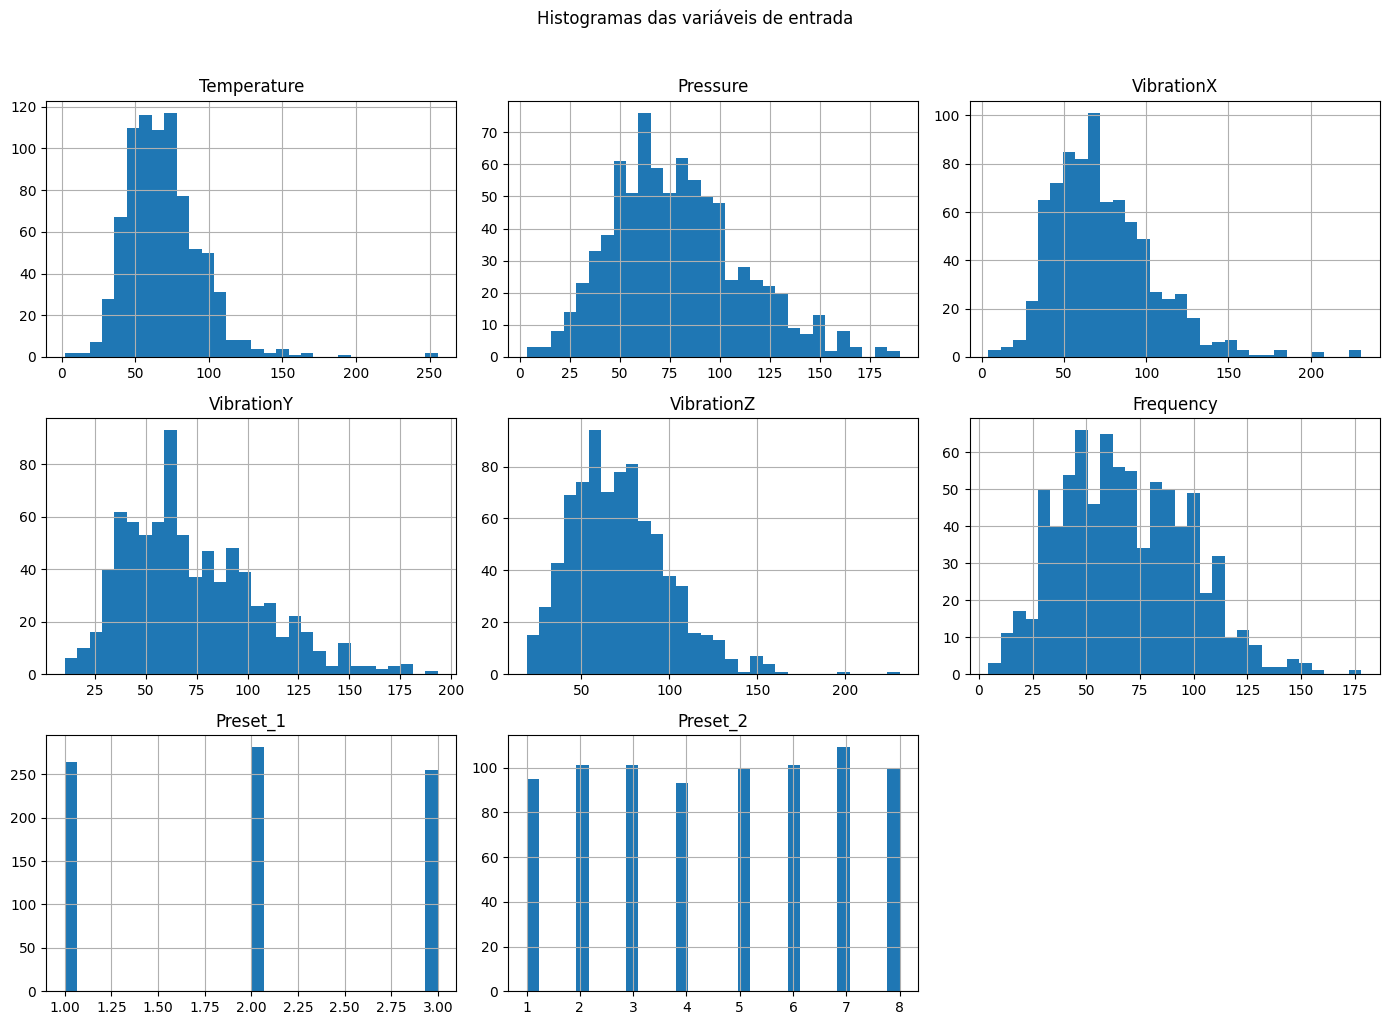

In [12]:
df[feature_cols].hist(figsize=(14, 10), bins=30)

plt.suptitle("Histogramas das variáveis de entrada", y=1.02)
plt.tight_layout()
plt.show()

## 1.9 Comparando médias por classe

### Perguntas para debate

1. Quais variáveis parecem ter médias diferentes entre as classes?
2. Uma diferença de médias garante que a variável será útil no modelo?
3. O tamanho da classe minoritária pode afetar essa comparação?


In [13]:
medias_por_classe = df.groupby(target)[feature_cols].mean().T

medias_por_classe.columns = ["media_classe_0", "media_classe_1"]
medias_por_classe["diferenca_1_menos_0"] = (
    medias_por_classe["media_classe_1"] - medias_por_classe["media_classe_0"]
)

medias_por_classe.sort_values("diferenca_1_menos_0", ascending=False)

,media_classe_0,media_classe_1,diferenca_1_menos_0
VibrationY,68.3185,122.4812,54.1627
Pressure,75.6328,116.4225,40.7897
VibrationZ,68.7967,106.0032,37.2065
Frequency,65.3830,99.8127,34.4297
VibrationX,71.4948,100.1672,28.6724
Temperature,67.1769,92.4691,25.2922
Preset_1,2.0000,1.8636,-0.1364
Preset_2,4.5627,4.4242,-0.1384


## 1.10 Correlação entre variáveis

### Perguntas para debate

1. O que significa duas variáveis terem correlação alta?
2. Uma variável pouco correlacionada com o alvo deve ser descartada automaticamente?
3. Modelos lineares e modelos baseados em árvores lidam da mesma forma com correlação?


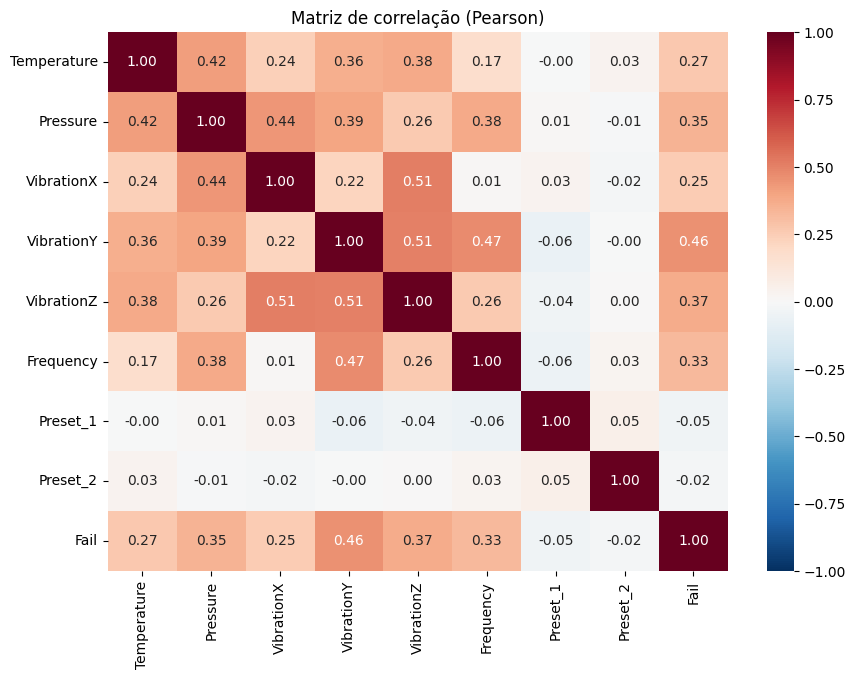

In [56]:
corr = df[feature_cols + [target]].corr(method="pearson")

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Matriz de correlação (Pearson)")
plt.show()

## 1.11 Uma olhada em variáveis de configuração

### Perguntas para debate

1. Quais variáveis parecem ter poucos valores únicos?
2. A taxa da classe positiva muda entre os valores dessas variáveis?
3. Uma diferença visual nas taxas é suficiente para concluir alguma coisa?


In [15]:
resumo_preset_1 = (
    df.groupby("Preset_1")[target]
    .agg(n_observacoes="size", positivos="sum", taxa_positiva="mean")
    .reset_index()
)

resumo_preset_1["taxa_positiva_percentual"] = (
    100 * resumo_preset_1["taxa_positiva"]
).round(2)

resumo_preset_1

,Preset_1,n_observacoes,positivos,taxa_positiva,taxa_positiva_percentual
0,1,264,27,0.1023,10.23
1,2,281,21,0.0747,7.47
2,3,255,18,0.0706,7.06


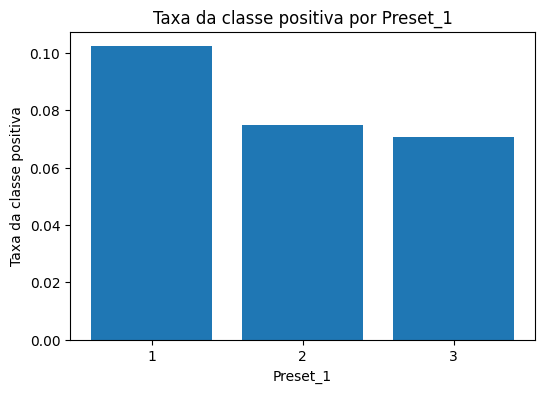

In [16]:
plt.figure(figsize=(6, 4))
plt.bar(resumo_preset_1["Preset_1"].astype(str), resumo_preset_1["taxa_positiva"])

plt.title("Taxa da classe positiva por Preset_1")
plt.xlabel("Preset_1")
plt.ylabel("Taxa da classe positiva")
plt.show()

In [17]:
resumo_preset_2 = (
    df.groupby("Preset_2")[target]
    .agg(n_observacoes="size", positivos="sum", taxa_positiva="mean")
    .reset_index()
)

resumo_preset_2["taxa_positiva_percentual"] = (
    100 * resumo_preset_2["taxa_positiva"]
).round(2)

resumo_preset_2

,Preset_2,n_observacoes,positivos,taxa_positiva,taxa_positiva_percentual
0,1,95,11,0.1158,11.58
1,2,101,9,0.0891,8.91
2,3,101,6,0.0594,5.94
3,4,93,3,0.0323,3.23
4,5,100,12,0.1200,12.00
5,6,101,9,0.0891,8.91
6,7,109,9,0.0826,8.26
7,8,100,7,0.0700,7.00


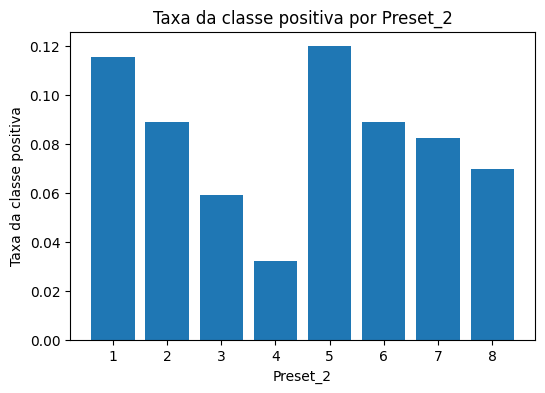

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(resumo_preset_2["Preset_2"].astype(str), resumo_preset_2["taxa_positiva"])

plt.title("Taxa da classe positiva por Preset_2")
plt.xlabel("Preset_2")
plt.ylabel("Taxa da classe positiva")
plt.show()

# Ato 2 — Primeiro modelo simples

## 2.1 Debate: normalização, treino/teste, desbalanceamento e pré-processamento

### Perguntas para a turma

1. Por que dividimos dados em treino e teste?
2. O que o conjunto de treino deve simular?
3. O que o conjunto de teste deve simular?
4. Por que normalizamos algumas variáveis antes de treinar determinados modelos?
5. O que pode dar errado se normalizarmos usando o dataset inteiro?
6. O que são dados desbalanceados?
7. Por que um bom EDA ajuda antes da modelagem?


## 2.2 Separando `X` e `y`

### Perguntas para debate

1. O que deve entrar em `X`?
2. O que deve entrar em `y`?
3. O que aconteceria se a variável-alvo fosse incluída em `X`?


In [19]:
X = df[feature_cols]
y = df[target]

display(X.head())
display(y.head())

,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Preset_1,Preset_2
0,44.2352,47.6573,46.4418,64.8203,66.4545,44.4832,3,6
1,60.8072,63.1721,62.0060,80.7144,81.2464,60.2287,2,4
2,79.0275,83.0322,82.6421,98.2544,98.7852,80.9935,2,1
3,79.7162,100.5086,122.3623,121.3634,118.6525,80.3156,2,3
4,39.9891,51.7648,42.5143,61.0379,50.7165,64.2452,2,5


,Fail
0,0
1,0
2,0
3,0
4,0


## 2.3 Divisão aleatória entre treino e teste

### Perguntas para debate

1. Por que não avaliamos o modelo nos mesmos dados usados para treino?
2. O que esperamos preservar ao usar `stratify=y`?
3. Por que pode ser útil começar pelo modelo mais simples possível?


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Tamanho do X_train:", X_train.shape)
print("Tamanho do X_test: ", X_test.shape)
print("Tamanho do y_train:", y_train.shape)
print("Tamanho do y_test: ", y_test.shape)

Tamanho do X_train: (640, 8)
Tamanho do X_test:  (160, 8)
Tamanho do y_train: (640,)
Tamanho do y_test:  (160,)


In [21]:
distribuicao_split_aleatorio = pd.DataFrame({
    "treino_n": y_train.value_counts().sort_index(),
    "teste_n": y_test.value_counts().sort_index()
}).fillna(0).astype(int)

distribuicao_split_aleatorio["treino_percentual"] = (
    100 * distribuicao_split_aleatorio["treino_n"] / distribuicao_split_aleatorio["treino_n"].sum()
).round(2)

distribuicao_split_aleatorio["teste_percentual"] = (
    100 * distribuicao_split_aleatorio["teste_n"] / distribuicao_split_aleatorio["teste_n"].sum()
).round(2)

distribuicao_split_aleatorio

,treino_n,teste_n,treino_percentual,teste_percentual
Fail,,,,
0,587,147,91.72,91.88
1,53,13,8.28,8.12


## 2.4 Normalização

### Perguntas para debate

1. Por que algumas variáveis precisam ser colocadas em escalas comparáveis?
2. Em qual conjunto devemos dar `fit` no normalizador?
3. Por que não devemos dar `fit` no conjunto de teste?


In [22]:
scaler_lr_baseline = StandardScaler()

scaler_lr_baseline.fit(X_train)

X_train_scaled = scaler_lr_baseline.transform(X_train)
X_test_scaled = scaler_lr_baseline.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_cols,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_cols,
    index=X_test.index
)

X_train_scaled.head()

,Temperature,Pressure,VibrationX,VibrationY,VibrationZ,Frequency,Preset_1,Preset_2
453,-0.1146,1.4213,-1.0661,-1.2749,-1.4982,-0.3743,1.2167,1.4693
575,0.1965,0.4736,-0.3513,0.7838,-0.3921,1.0513,1.2167,0.1693
673,0.2366,2.0026,0.5183,-0.4345,-0.0798,0.9807,1.2167,1.0359
277,-0.3764,0.1829,-0.3797,0.3253,-0.3947,-0.4874,-0.0135,-1.5640
76,-0.1591,0.2929,-0.7847,0.3216,-0.9679,-0.4809,-0.0135,-1.5640


In [23]:
checagem_normalizacao = pd.DataFrame({
    "media_treino": X_train_scaled.mean().round(2),
    "desvio_treino": X_train_scaled.std().round(2),
    "media_teste": X_test_scaled.mean().round(2),
    "desvio_teste": X_test_scaled.std().round(2)
})

checagem_normalizacao

,media_treino,desvio_treino,media_teste,desvio_teste
Temperature,0.0,1.0,-0.06,0.90
Pressure,-0.0,1.0,-0.13,0.85
VibrationX,-0.0,1.0,0.19,1.10
VibrationY,-0.0,1.0,-0.01,0.97
VibrationZ,-0.0,1.0,0.01,0.95
Frequency,-0.0,1.0,-0.09,0.86
Preset_1,0.0,1.0,-0.14,0.95
Preset_2,-0.0,1.0,-0.13,0.96


### Pergunta rápida

1. Por que a média do treino fica perto de `0`, mas a média do teste não precisa ficar exatamente em `0`?


## 2.5 Modelo 1 — Regressão logística com dados desbalanceados

### Perguntas para debate

1. Por que um modelo chamado regressão logística pode ser usado em classificação?
2. O que a probabilidade prevista pelo modelo representa?
3. O limiar de `0.50` é sempre adequado?


In [24]:
lr_baseline = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_STATE
)

lr_baseline.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [25]:
y_proba_lr_baseline = lr_baseline.predict_proba(X_test_scaled)[:, 1]

y_pred_lr_baseline = (y_proba_lr_baseline >= 0.50).astype(int)

pd.DataFrame({
    "real": y_test,
    "probabilidade_classe_1": y_proba_lr_baseline,
    "predito": y_pred_lr_baseline
}).head(10)

,real,probabilidade_classe_1,predito
250,0,5.6829e-05,0
129,0,1.7265e-04,0
564,0,1.4226e-03,0
342,0,8.9856e-04,0
785,0,1.7949e-02,0
609,0,2.0484e-02,0
690,0,3.5691e-04,0
166,0,4.0190e-05,0
747,0,1.2754e-02,0
131,0,1.4642e-02,0


## 2.6 Avaliação do primeiro modelo

### Perguntas para debate

1. Por que a acurácia pode não contar a história inteira?
2. O que precision e recall podem revelar que a acurácia esconde?
3. O que a curva ROC pode acrescentar à avaliação?


In [26]:
cm_lr_baseline = confusion_matrix(
    y_test,
    y_pred_lr_baseline,
    labels=[0, 1]
)

cm_lr_baseline_df = pd.DataFrame(
    cm_lr_baseline,
    index=["real_0", "real_1"],
    columns=["predito_0", "predito_1"]
)

cm_lr_baseline_df

,predito_0,predito_1
real_0,145,2
real_1,7,6


In [27]:
tn_lr_baseline, fp_lr_baseline, fn_lr_baseline, tp_lr_baseline = cm_lr_baseline.ravel()

accuracy_lr_baseline = accuracy_score(y_test, y_pred_lr_baseline)
precision_lr_baseline = precision_score(y_test, y_pred_lr_baseline, zero_division=0)
recall_lr_baseline = recall_score(y_test, y_pred_lr_baseline, zero_division=0)
f1_lr_baseline = f1_score(y_test, y_pred_lr_baseline, zero_division=0)
roc_auc_lr_baseline = roc_auc_score(y_test, y_proba_lr_baseline)

metricas_lr_baseline = pd.DataFrame([{
    "experimento": "Modelo 1 - Regressao Logistica - desbalanceado",
    "dados_treino": "desbalanceados",
    "modelo": "Regressao Logistica",
    "accuracy": accuracy_lr_baseline,
    "precision": precision_lr_baseline,
    "recall": recall_lr_baseline,
    "f1": f1_lr_baseline,
    "roc_auc": roc_auc_lr_baseline,
    "tn": tn_lr_baseline,
    "fp": fp_lr_baseline,
    "fn": fn_lr_baseline,
    "tp": tp_lr_baseline
}])

metricas_lr_baseline

,experimento,dados_treino,modelo,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Modelo 1 - Regressao Logistica - desbalanceado,desbalanceados,Regressao Logistica,0.9437,0.75,0.4615,0.5714,0.9785,145,2,7,6


In [28]:
print(classification_report(
    y_test,
    y_pred_lr_baseline,
    labels=[0, 1],
    target_names=["classe_0", "classe_1"],
    zero_division=0
))

              precision    recall  f1-score   support

    classe_0       0.95      0.99      0.97       147
    classe_1       0.75      0.46      0.57        13

    accuracy                           0.94       160
   macro avg       0.85      0.72      0.77       160
weighted avg       0.94      0.94      0.94       160



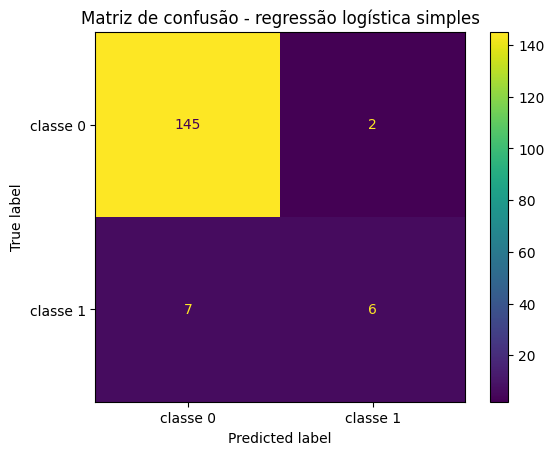

In [29]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_baseline,
    display_labels=["classe 0", "classe 1"]
).plot(values_format="d")

plt.title("Matriz de confusão - regressão logística simples")
plt.show()

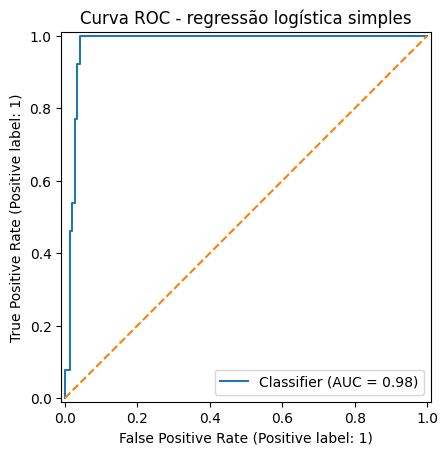

AUC: 0.9785


In [30]:
RocCurveDisplay.from_predictions(y_test, y_proba_lr_baseline)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - regressão logística simples")
plt.show()

print(f"AUC: {roc_auc_lr_baseline:.4f}")

# Ato 3 — Interpretando, diagnosticando e melhorando

## 3.0 Debate interpretativo: o que significam as métricas?

### Perguntas para a turma

1. O que representa cada célula da matriz de confusão?
2. Qual é a diferença entre falso positivo e falso negativo?
3. O que precision responde sobre as previsões positivas?
4. O que recall responde sobre os casos positivos reais?
5. O que o f1-score tenta equilibrar?
6. Como a curva ROC ajuda a comparar limiares de decisão?
7. Dado o primeiro resultado, quais hipóteses podemos testar para melhorar?


## 3.1 Balanceamento de classe com SMOTE

### Perguntas para debate

1. Por que não balanceamos o conjunto de teste?
2. Qual é a diferença entre usar SMOTE e apenas alterar o peso das classes?
3. Como saber se o balanceamento ajudou ou apenas mudou o tipo de erro?


In [31]:
menor_classe_treino = y_train.value_counts().min()

k_vizinhos_smote = min(5, menor_classe_treino - 1)

print("Menor classe no treino:", menor_classe_treino)
print("k_neighbors usado no SMOTE:", k_vizinhos_smote)

Menor classe no treino: 53
k_neighbors usado no SMOTE: 5


In [32]:
smote = SMOTE(
    random_state=RANDOM_STATE,
    k_neighbors=k_vizinhos_smote
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

X_train_smote = pd.DataFrame(
    X_train_smote,
    columns=feature_cols
)

y_train_smote = pd.Series(
    y_train_smote,
    name=target
)

distribuicao_smote = pd.DataFrame({
    "antes_do_smote": y_train.value_counts().sort_index(),
    "depois_do_smote": y_train_smote.value_counts().sort_index()
}).fillna(0).astype(int)

distribuicao_smote

,antes_do_smote,depois_do_smote
Fail,,
0,587,587
1,53,587


## 3.2 Modelo 2 — Regressão logística com SMOTE

### Perguntas para debate

1. O que muda em relação à regressão logística anterior?
2. O balanceamento do treino muda a distribuição do teste?
3. Como decidir se o SMOTE ajudou?


In [33]:
lr_smote = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_STATE,
    class_weight=None
)

lr_smote.fit(X_train_smote, y_train_smote)

y_proba_lr_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]
y_pred_lr_smote = (y_proba_lr_smote >= 0.50).astype(int)

In [34]:
cm_lr_smote = confusion_matrix(
    y_test,
    y_pred_lr_smote,
    labels=[0, 1]
)

cm_lr_smote_df = pd.DataFrame(
    cm_lr_smote,
    index=["real_0", "real_1"],
    columns=["predito_0", "predito_1"]
)

cm_lr_smote_df

,predito_0,predito_1
real_0,138,9
real_1,0,13


In [35]:
tn_lr_smote, fp_lr_smote, fn_lr_smote, tp_lr_smote = cm_lr_smote.ravel()

accuracy_lr_smote = accuracy_score(y_test, y_pred_lr_smote)
precision_lr_smote = precision_score(y_test, y_pred_lr_smote, zero_division=0)
recall_lr_smote = recall_score(y_test, y_pred_lr_smote, zero_division=0)
f1_lr_smote = f1_score(y_test, y_pred_lr_smote, zero_division=0)
roc_auc_lr_smote = roc_auc_score(y_test, y_proba_lr_smote)

metricas_lr_smote = pd.DataFrame([{
    "experimento": "Modelo 2 - Regressao Logistica - SMOTE",
    "dados_treino": "balanceados com SMOTE",
    "modelo": "Regressao Logistica",
    "accuracy": accuracy_lr_smote,
    "precision": precision_lr_smote,
    "recall": recall_lr_smote,
    "f1": f1_lr_smote,
    "roc_auc": roc_auc_lr_smote,
    "tn": tn_lr_smote,
    "fp": fp_lr_smote,
    "fn": fn_lr_smote,
    "tp": tp_lr_smote
}])

metricas_lr_smote

,experimento,dados_treino,modelo,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Modelo 2 - Regressao Logistica - SMOTE,balanceados com SMOTE,Regressao Logistica,0.9437,0.5909,1.0,0.7429,0.9801,138,9,0,13


In [36]:
print(classification_report(
    y_test,
    y_pred_lr_smote,
    labels=[0, 1],
    target_names=["classe_0", "classe_1"],
    zero_division=0
))

              precision    recall  f1-score   support

    classe_0       1.00      0.94      0.97       147
    classe_1       0.59      1.00      0.74        13

    accuracy                           0.94       160
   macro avg       0.80      0.97      0.86       160
weighted avg       0.97      0.94      0.95       160



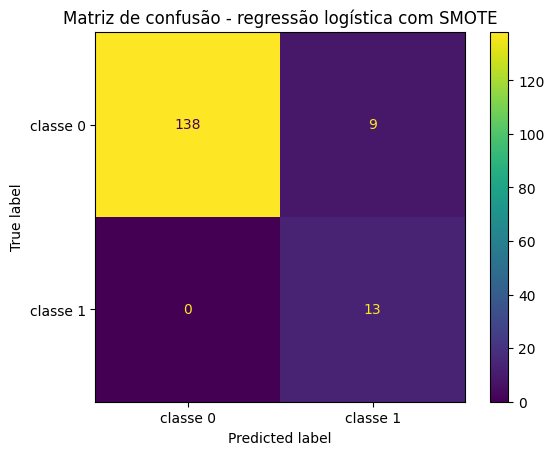

In [37]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_smote,
    display_labels=["classe 0", "classe 1"]
).plot(values_format="d")

plt.title("Matriz de confusão - regressão logística com SMOTE")
plt.show()

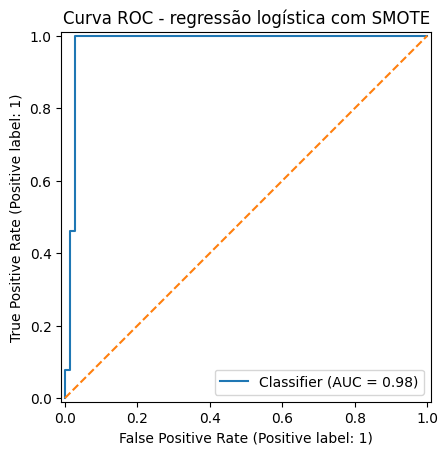

AUC: 0.9801


In [38]:
RocCurveDisplay.from_predictions(y_test, y_proba_lr_smote)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - regressão logística com SMOTE")
plt.show()

print(f"AUC: {roc_auc_lr_smote:.4f}")

## 3.3 Modelo 3 — Random Forest com `class_weight` e dados desbalanceados

### Perguntas para debate

1. O que muda quando saímos de regressão logística para Random Forest?
2. Por que testar `class_weight` em dados desbalanceados?
3. Um modelo mais complexo sempre melhora o resultado?


In [39]:
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    min_samples_leaf=2,
    n_jobs=1
)

rf_weighted.fit(X_train_scaled, y_train)

y_proba_rf_weighted = rf_weighted.predict_proba(X_test_scaled)[:, 1]
y_pred_rf_weighted = (y_proba_rf_weighted >= 0.50).astype(int)

In [40]:
cm_rf_weighted = confusion_matrix(
    y_test,
    y_pred_rf_weighted,
    labels=[0, 1]
)

cm_rf_weighted_df = pd.DataFrame(
    cm_rf_weighted,
    index=["real_0", "real_1"],
    columns=["predito_0", "predito_1"]
)

cm_rf_weighted_df

,predito_0,predito_1
real_0,144,3
real_1,2,11


In [41]:
tn_rf_weighted, fp_rf_weighted, fn_rf_weighted, tp_rf_weighted = cm_rf_weighted.ravel()

accuracy_rf_weighted = accuracy_score(y_test, y_pred_rf_weighted)
precision_rf_weighted = precision_score(y_test, y_pred_rf_weighted, zero_division=0)
recall_rf_weighted = recall_score(y_test, y_pred_rf_weighted, zero_division=0)
f1_rf_weighted = f1_score(y_test, y_pred_rf_weighted, zero_division=0)
roc_auc_rf_weighted = roc_auc_score(y_test, y_proba_rf_weighted)

metricas_rf_weighted = pd.DataFrame([{
    "experimento": "Modelo 3 - Random Forest - class_weight",
    "dados_treino": "desbalanceados",
    "modelo": "Random Forest",
    "accuracy": accuracy_rf_weighted,
    "precision": precision_rf_weighted,
    "recall": recall_rf_weighted,
    "f1": f1_rf_weighted,
    "roc_auc": roc_auc_rf_weighted,
    "tn": tn_rf_weighted,
    "fp": fp_rf_weighted,
    "fn": fn_rf_weighted,
    "tp": tp_rf_weighted
}])

metricas_rf_weighted

,experimento,dados_treino,modelo,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Modelo 3 - Random Forest - class_weight,desbalanceados,Random Forest,0.9688,0.7857,0.8462,0.8148,0.9859,144,3,2,11


In [42]:
print(classification_report(
    y_test,
    y_pred_rf_weighted,
    labels=[0, 1],
    target_names=["classe_0", "classe_1"],
    zero_division=0
))

              precision    recall  f1-score   support

    classe_0       0.99      0.98      0.98       147
    classe_1       0.79      0.85      0.81        13

    accuracy                           0.97       160
   macro avg       0.89      0.91      0.90       160
weighted avg       0.97      0.97      0.97       160



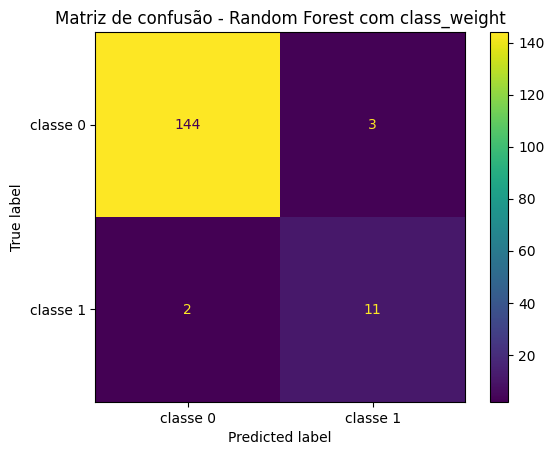

In [43]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_weighted,
    display_labels=["classe 0", "classe 1"]
).plot(values_format="d")

plt.title("Matriz de confusão - Random Forest com class_weight")
plt.show()

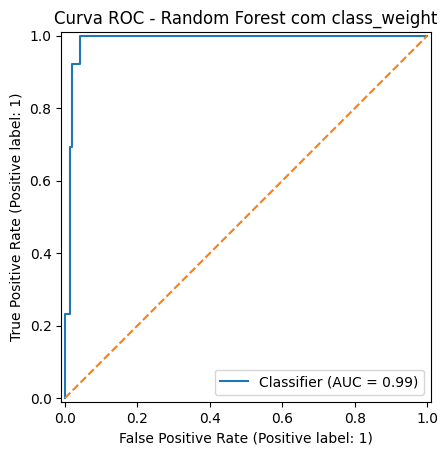

AUC: 0.9859


In [44]:
RocCurveDisplay.from_predictions(y_test, y_proba_rf_weighted)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - Random Forest com class_weight")
plt.show()

print(f"AUC: {roc_auc_rf_weighted:.4f}")

## 3.4 Importância de variáveis na Random Forest

### Perguntas para debate

1. Quais variáveis aparecem como mais importantes?
2. Importância de variável prova causalidade?
3. A importância pode mudar se mudarmos o split ou os hiperparâmetros?


In [45]:
importancias_rf = pd.Series(
    rf_weighted.feature_importances_,
    index=feature_cols
).sort_values()

importancias_rf

,0
Preset_1,0.0142
Preset_2,0.0149
Temperature,0.1149
VibrationX,0.1271
Pressure,0.1423
VibrationZ,0.1813
Frequency,0.1933
VibrationY,0.2120


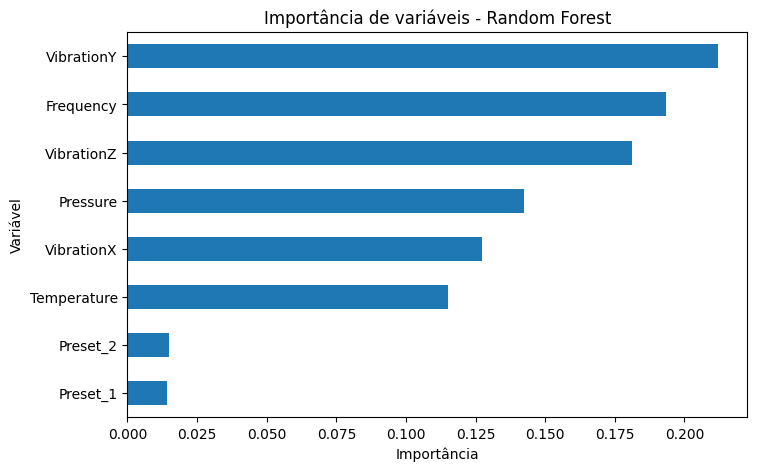

In [46]:
plt.figure(figsize=(8, 5))
importancias_rf.plot(kind="barh")

plt.title("Importância de variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

## 3.5 Modelo 4 — Random Forest com SMOTE

### Perguntas para debate

1. O que muda em relação à Random Forest com `class_weight`?
2. O SMOTE afeta modelos lineares e modelos baseados em árvores da mesma forma?
3. Que resultado indicaria que o modelo está gerando positivos demais?


In [47]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight=None,
    min_samples_leaf=2,
    n_jobs=1
)

rf_smote.fit(X_train_smote, y_train_smote)

y_proba_rf_smote = rf_smote.predict_proba(X_test_scaled)[:, 1]
y_pred_rf_smote = (y_proba_rf_smote >= 0.50).astype(int)

In [48]:
cm_rf_smote = confusion_matrix(
    y_test,
    y_pred_rf_smote,
    labels=[0, 1]
)

cm_rf_smote_df = pd.DataFrame(
    cm_rf_smote,
    index=["real_0", "real_1"],
    columns=["predito_0", "predito_1"]
)

cm_rf_smote_df

,predito_0,predito_1
real_0,143,4
real_1,1,12


In [49]:
tn_rf_smote, fp_rf_smote, fn_rf_smote, tp_rf_smote = cm_rf_smote.ravel()

accuracy_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
precision_rf_smote = precision_score(y_test, y_pred_rf_smote, zero_division=0)
recall_rf_smote = recall_score(y_test, y_pred_rf_smote, zero_division=0)
f1_rf_smote = f1_score(y_test, y_pred_rf_smote, zero_division=0)
roc_auc_rf_smote = roc_auc_score(y_test, y_proba_rf_smote)

metricas_rf_smote = pd.DataFrame([{
    "experimento": "Modelo 4 - Random Forest - SMOTE",
    "dados_treino": "balanceados com SMOTE",
    "modelo": "Random Forest",
    "accuracy": accuracy_rf_smote,
    "precision": precision_rf_smote,
    "recall": recall_rf_smote,
    "f1": f1_rf_smote,
    "roc_auc": roc_auc_rf_smote,
    "tn": tn_rf_smote,
    "fp": fp_rf_smote,
    "fn": fn_rf_smote,
    "tp": tp_rf_smote
}])

metricas_rf_smote

,experimento,dados_treino,modelo,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Modelo 4 - Random Forest - SMOTE,balanceados com SMOTE,Random Forest,0.9688,0.75,0.9231,0.8276,0.9817,143,4,1,12


In [50]:
print(classification_report(
    y_test,
    y_pred_rf_smote,
    labels=[0, 1],
    target_names=["classe_0", "classe_1"],
    zero_division=0
))

              precision    recall  f1-score   support

    classe_0       0.99      0.97      0.98       147
    classe_1       0.75      0.92      0.83        13

    accuracy                           0.97       160
   macro avg       0.87      0.95      0.91       160
weighted avg       0.97      0.97      0.97       160



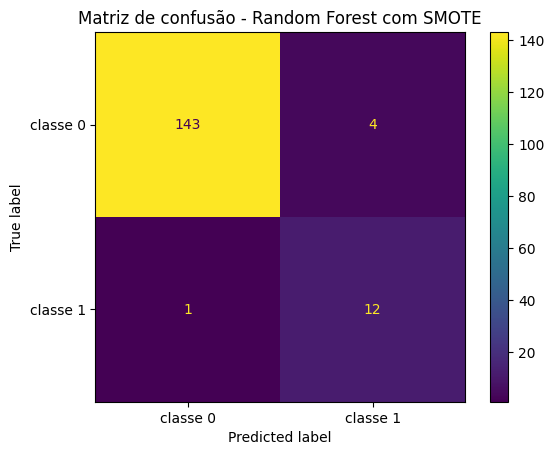

In [51]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_smote,
    display_labels=["classe 0", "classe 1"]
).plot(values_format="d")

plt.title("Matriz de confusão - Random Forest com SMOTE")
plt.show()

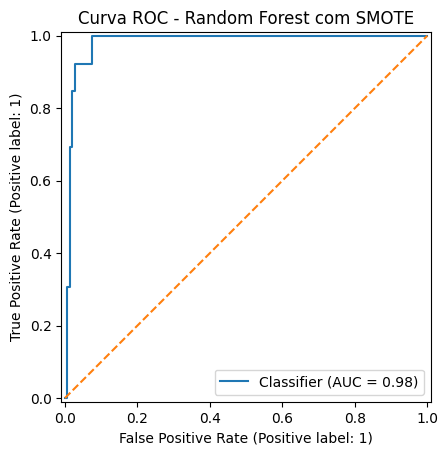

AUC: 0.9817


In [52]:
RocCurveDisplay.from_predictions(y_test, y_proba_rf_smote)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - Random Forest com SMOTE")
plt.show()

print(f"AUC: {roc_auc_rf_smote:.4f}")

## 3.6 Comparando os quatro modelos

### Perguntas para debate

1. Qual modelo teve maior recall, precision e f1-score?
2. Algum modelo parece bom em uma métrica, mas ruim em outra?
3. Qual modelo você escolheria para investigar mais? Por quê?


In [53]:
resultados_test = pd.concat([
    metricas_lr_baseline,
    metricas_lr_smote,
    metricas_rf_weighted,
    metricas_rf_smote
], ignore_index=True)

resultados_test.sort_values("f1", ascending=False)

,experimento,dados_treino,modelo,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
3,Modelo 4 - Random Forest - SMOTE,balanceados com SMOTE,Random Forest,0.9688,0.7500,0.9231,0.8276,0.9817,143,4,1,12
2,Modelo 3 - Random Forest - class_weight,desbalanceados,Random Forest,0.9688,0.7857,0.8462,0.8148,0.9859,144,3,2,11
1,Modelo 2 - Regressao Logistica - SMOTE,balanceados com SMOTE,Regressao Logistica,0.9437,0.5909,1.0000,0.7429,0.9801,138,9,0,13
0,Modelo 1 - Regressao Logistica - desbalanceado,desbalanceados,Regressao Logistica,0.9437,0.7500,0.4615,0.5714,0.9785,145,2,7,6


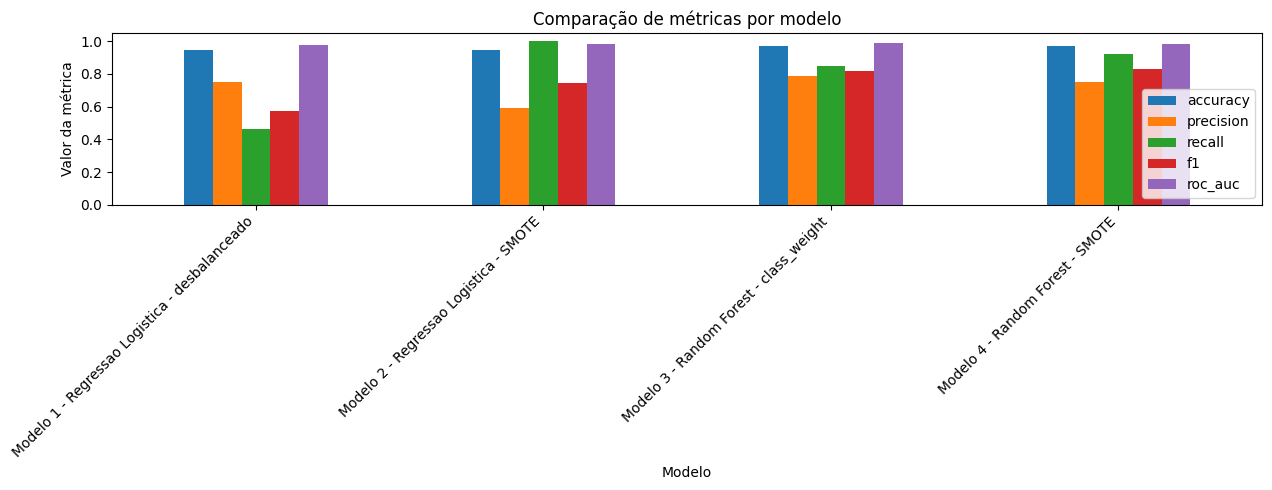

In [54]:
metricas_para_grafico = resultados_test.set_index("experimento")[
    ["accuracy", "precision", "recall", "f1", "roc_auc"]
]

metricas_para_grafico.plot(kind="bar", figsize=(13, 5))

plt.title("Comparação de métricas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Valor da métrica")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 3.7 Discussão: o que tentar depois?

### Perguntas para próximos experimentos

1. O que aconteceria se ajustássemos o limiar de decisão em vez de usar sempre `0.50`?
2. Como poderíamos testar se uma divisão temporal muda a avaliação do modelo?
3. Quando faria sentido comparar classificação supervisionada com detecção de anomalias?
4. Eu quero prever não apenas o momento da falha, mas operações perto do limite operacional da máquina, isso permitiria aumentar a quantidade de observações de "fail".


# Fechamento — Como pensar como cientista de dados

## Perguntas finais para a turma

1. Qual foi o principal diagnóstico depois do primeiro modelo?
2. Qual hipótese o SMOTE testou?
3. Qual hipótese o `class_weight` testou?
4. Que evidência faria você escolher um dos quatro modelos?
5. Como poderíamos testar, em uma próxima aula, a hipótese de que o split temporal muda a avaliação?
6. Que outro experimento futuro você testaria: ajuste de limiar, novas variáveis, validação cruzada, outro modelo ou detecção de anomalias?
7. Como você explicaria o ciclo diagnóstico → hipótese → experimento → evidência → novo diagnóstico?
